In [1]:
import pandas as pd
import numpy as np
from dython.nominal import associations
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# 'Malgun Gothic' 폰트를 기본으로 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_parquet("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/ABC추출.parquet")

In [5]:
df

,기준년월,ID,남녀구분코드,연령,Segment,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,...,승인거절건수_한도초과_B0M,승인거절건수_BL_B0M,승인거절건수_입력오류_B0M,승인거절건수_기타_B0M,승인거절건수_R3M,승인거절건수_한도초과_R3M,승인거절건수_BL_R3M,승인거절건수_입력오류_R3M,승인거절건수_기타_R3M,이용금액대
0,201807,TRAIN_000002,1,30대,C,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,01.100만원+
1,201807,TRAIN_000008,1,30대,C,1,1,1,1,3,...,0,0,0,0,0,0,0,0,0,01.100만원+
2,201807,TRAIN_000037,1,50대,C,1,1,1,1,3,...,0,0,0,0,0,0,0,0,0,01.100만원+
3,201807,TRAIN_000039,2,30대,C,1,1,1,1,3,...,0,0,0,0,0,0,0,0,0,01.100만원+
4,201807,TRAIN_000055,1,60대,C,1,1,0,1,2,...,0,0,0,0,0,0,0,0,0,01.100만원+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128701,201812,TRAIN_399911,1,40대,C,1,1,1,1,2,...,0,0,0,0,0,0,0,0,0,01.100만원+
128702,201812,TRAIN_399953,1,50대,C,1,1,1,1,3,...,0,0,0,0,0,0,0,0,0,01.100만원+
128703,201812,TRAIN_399987,1,50대,C,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,01.100만원+
128704,201812,TRAIN_399993,1,40대,C,1,1,1,1,3,...,0,0,0,0,0,0,0,0,0,01.100만원+


In [7]:
na_counts = df.isna().sum()
na_cols = na_counts[na_counts >0]
print(na_cols)

Series([], dtype: int64)


- 상관계수를 구하기 위해 결측치가 있는 모든 컬럼은 제거한다. 

In [38]:
df = df.dropna(axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Columns: 831 entries, 기준년월 to 이용금액대
dtypes: float64(54), int64(747), object(30)
memory usage: 7.1+ MB


In [9]:
# LabelEncoder 하기

obj_cols = df.select_dtypes(include='object').columns

for col in obj_cols:
    le = LabelEncoder()
    df.loc[:, col] = le.fit_transform(df[col].astype(str))

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128706 entries, 0 to 128705
Columns: 827 entries, 기준년월 to 이용금액대
dtypes: float64(52), int64(747), object(28)
memory usage: 812.1+ MB


In [11]:
correlations = df.corr()["Segment"].sort_values(ascending=False)

In [19]:
significant_corr = correlations[correlations.abs() >= 0.15]
significant_corr_sorted = significant_corr.reindex(significant_corr.abs().sort_values(ascending=False).index)

print(significant_corr_sorted)

Segment       1.000000
정상청구원금_B5M   -0.200975
정상입금원금_B5M   -0.186881
정상청구원금_B2M   -0.182056
청구금액_R6M     -0.181916
정상입금원금_B2M   -0.178739
청구금액_R3M     -0.177000
정상입금원금_B0M   -0.175360
정상청구원금_B0M   -0.174731
청구금액_B0      -0.168631
Name: Segment, dtype: float64


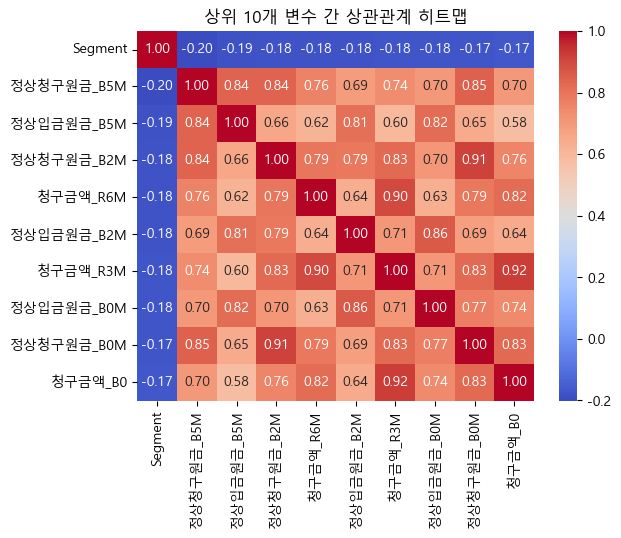

In [21]:
# Segment와 관련 있는 상위 10개 변수만 선택
top_features = correlations.abs().sort_values(ascending=False).head(10).index
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("상위 10개 변수 간 상관관계 히트맵")
plt.show()